In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import networkx as nx
from scipy.linalg import eig


# Pricing weather derivatives with Markov Chains using transition matrices.
### Pratyush · Linear Algebra · May 4, 2026

---

## 1. Introduction
This is part of my independent study.  Throughout this study, we've been studying Steven Shreve's Stochastic Calculus for finance



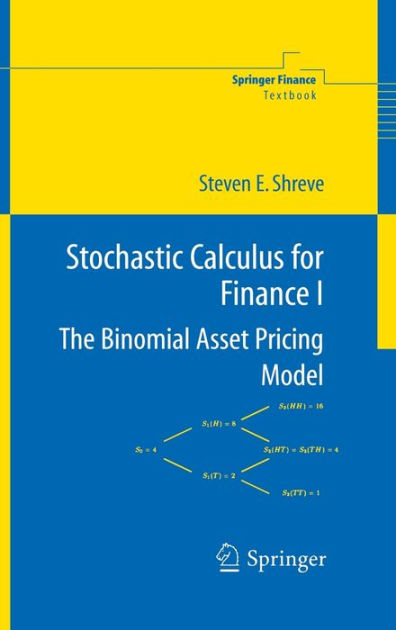



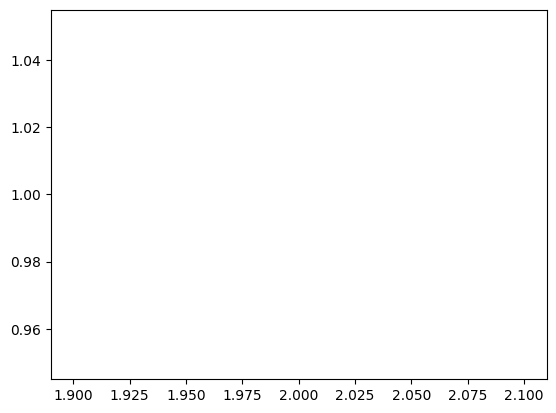

In [9]:

import numpy as np
import matplotlib.pyplot as plt 


y = 1
x = 2*y
mpl.plot(x,y)







This is just a markdown $$f'(a) = \lim_{x \to a} \frac{f(x) - f(a)}{x-a}$$
This is just a markdown $$f'(a) = \lim_{x \to a} \frac{f(x) - f(a)}{x-a}$$






Weather derivatives are financial instruments whose payoff depends on meteorological
variables such as temperature, rainfall, or snowfall. Unlike traditional derivatives,
their underlying asset, weather, is not tradable, making classical no-arbitrage
pricing inapplicable. In this project, we model temperature dynamics as a
**discrete-time Markov chain** and use tools from linear algebra, transition matrices,
eigendecomposition, and stationary distributions, to price a temperature-based
derivative contract. 



$$$$

## 2. Methods

Here we define the weather as a set of discrete states where the core of the model is the Transition Matrix, where each entry 
 represents the probability of moving from state 
 to state 

## 1. Weather Derivatives: Background

Weather derivatives emerged in the late 1990s to help energy companies hedge against
revenue losses caused by mild winters or cool summers. A typical contract is a
**Heating Degree Day (HDD)** swap, which pays based on how far daily temperature
falls below a reference (usually 65°F / 18°C):

$$\text{HDD}_t = \max(T_{\text{ref}} - T_t,\ 0)$$

The contract payoff over a season with $N$ days is:

$$\text{Payoff} = \alpha \cdot \sum_{t=1}^{N} \text{HDD}_t$$

where $\alpha$ is the **tick size** (dollars per degree-day).

> **Key challenge:** $T_t$ is a random variable. To price this contract, we need
> the distribution of $\sum_{t=1}^N \text{HDD}_t$ — which requires a model for
> how temperature evolves over time.